In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\INBSI2\OneDrive - Laerdal Medical AS\Documents\bipra\Data Set\heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
# Find the column information and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
# Find the Statistical information of the numerical columns
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Find the missing values
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
# Find if there is any duplicate data
df.duplicated().sum()

np.int64(0)

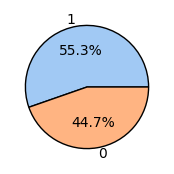

In [7]:
# Check if the output column HeartDisease is equally distributed
plt.figure(figsize=(2,2))
df['HeartDisease'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'),
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.show()

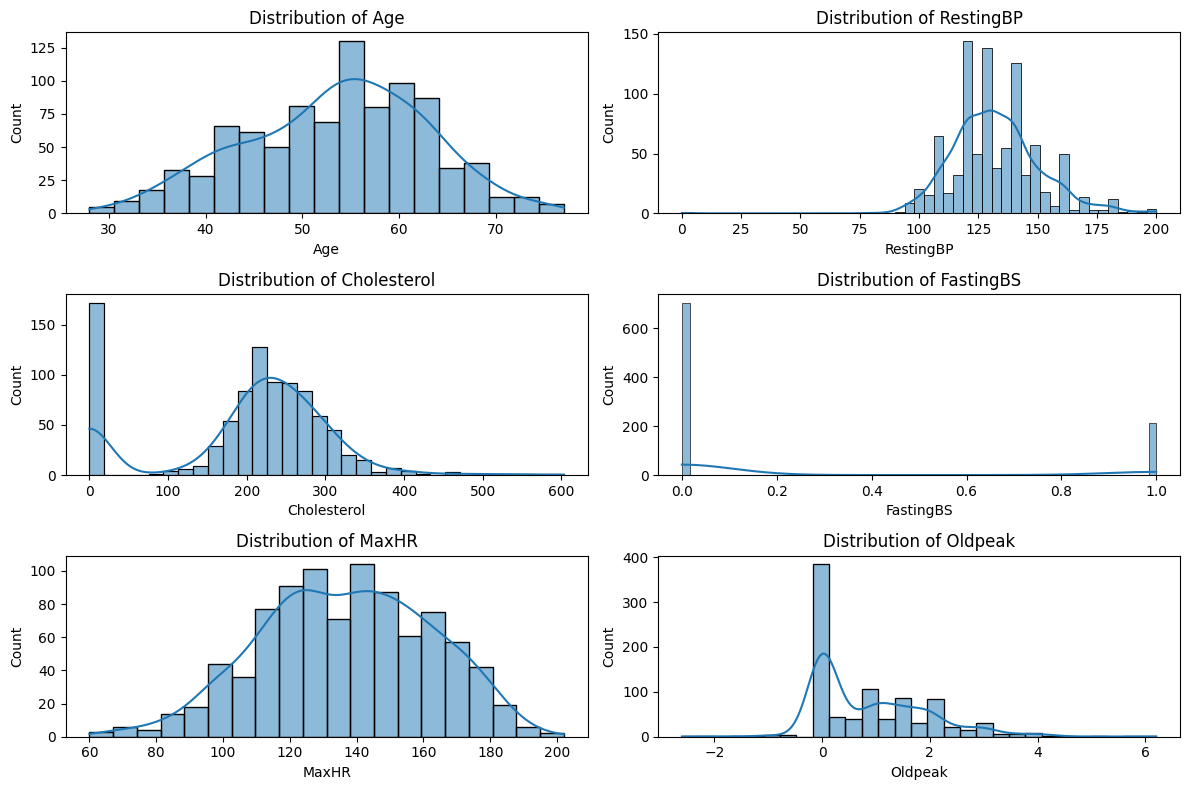

In [8]:
# Plot the distribution of the numerical columns
numerical_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
no_of_rows = int((len(numerical_columns)+1)/2)
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

From the above distribution curves, we could see that the Resting BP, Cholestrol, Oldpeak has some 0 value, which is not correct. So, we need to correct the wrong data.

In [9]:
# Replace the wrong values with mean
resting_bp_mean = df.loc[df['RestingBP']!=0, 'RestingBP'].mean()
cholesterol_mean = df.loc[df['Cholesterol']!=0, 'Cholesterol'].median()
oldpeak_mean = df.loc[df['Oldpeak']!=0, 'Oldpeak'].mean()

df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['Cholesterol'] = df['Cholesterol'].replace(0, cholesterol_mean)
df['Oldpeak'] = df['Oldpeak'].replace(0, oldpeak_mean)

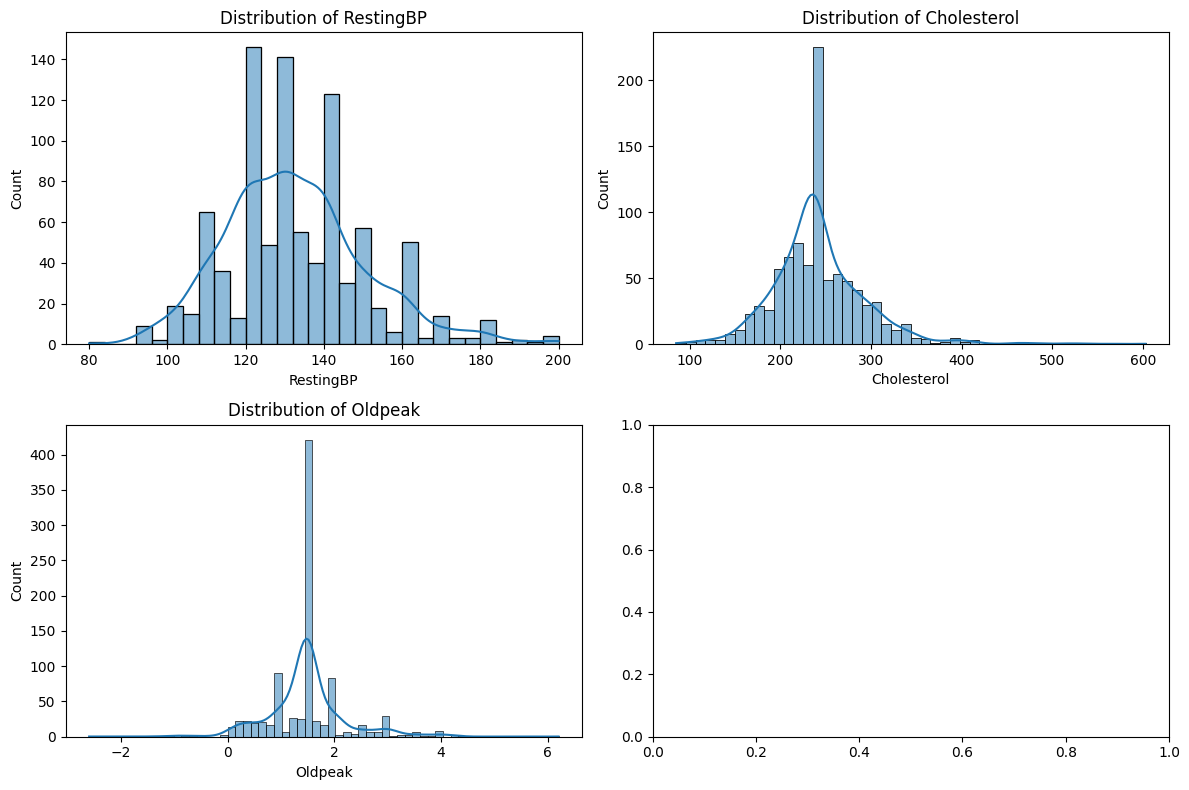

In [10]:
# Plot the distribution of the numerical columns again after correction
numerical_columns = ['RestingBP', 'Cholesterol', 'Oldpeak']
no_of_rows = int((len(numerical_columns)+1)/2)
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

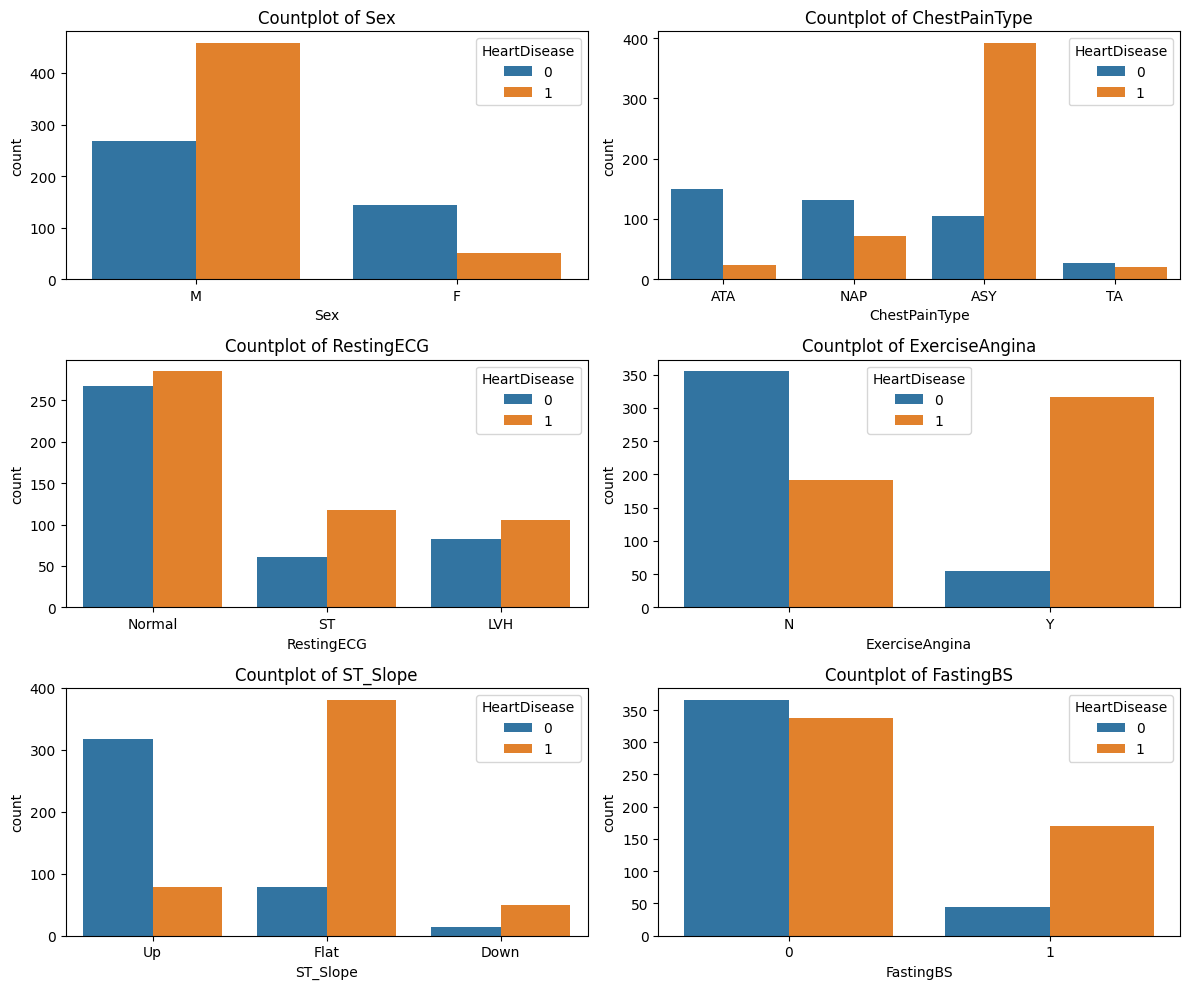

In [11]:
# Visulize the categorical columns using countplot
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
no_of_rows = int((len(categorical_columns)+1)/2)
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

<Axes: >

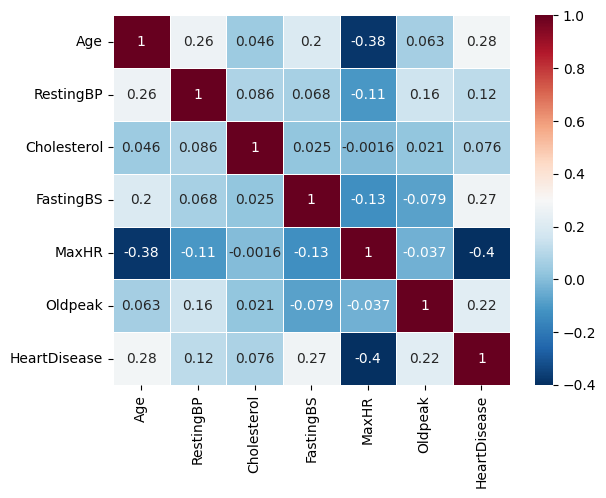

In [12]:
# Correlation between the data fields
cor_matrix = df.corr(numeric_only=True)
sns.heatmap(cor_matrix, annot=True, linewidths=0.5, cmap='RdBu_r')

The correlation heatmap shows that MaxHR has the strongest correlation with HeartDisease (-0.40), followed by Age (0.28), FastingBS (0.27), and Oldpeak (0.22). This suggests that MaxHR has moderately negative relation with heart disease, while Age, FastingBS, and Oldpeak have a moderate to weak positive association with the target variable.

In [13]:
# Onehot Encoding: Create new columns for all the categorical columns
df = pd.get_dummies(data=df).astype(int)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,1,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,1,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,1,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [14]:
# Feature Scaling: Convert the numerical columns into standard form (mean=0, std=1)
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
s = StandardScaler()
df[cols] = s.fit_transform(df[cols])
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.858035,0,1.382928,-0.15088,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.184227,0,0.754157,-0.15088,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.745617,0,-1.525138,-0.15088,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.547191,0,-1.132156,-0.15088,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.903182,0,-0.581981,-0.15088,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [19]:
# Seggregate the input and output
x = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [21]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

In [30]:
# Find the best K value for K Nearest Neighbour
scores = []
for k in range(1, int(np.sqrt(len(df)))):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn_model, x, y, cv=5, scoring='accuracy')
    scores.append(cv_score.mean())
best_k = scores.index(max(scores))+1
best_k

17

In [31]:
# Create a dictionary of models
models = {'Logistic Regression': LogisticRegression(),
          'K Nearest Neighbour': KNeighborsClassifier(n_neighbors=best_k),
          'Gaussian Naive Bayes': GaussianNB(),
          'Decision Tree': DecisionTreeClassifier(random_state=42),
          'Support Vector Machine': SVC()}

In [50]:
# Training and Evaluating all the models using a for loop
results = []
for model_name, model_algorithm in models.items():
    model_algorithm.fit(x_train, y_train)
    y_pred = model_algorithm.predict(x_test)
    accuracy = round(accuracy_score(y_test, y_pred),4)*100
    precision = round(precision_score(y_test, y_pred),4)*100
    recall = round(recall_score(y_test, y_pred),4)*100
    f1 = round(f1_score(y_test, y_pred),4)*100
    train_accuracy = model_algorithm.score(x_train, y_train)*100
    test_accuracy = model_algorithm.score(x_test, y_test)*100
    fit = 'Good Fit' if abs(train_accuracy-test_accuracy)<5 else 'Slight Overfit' if abs(train_accuracy-test_accuracy)<10 else 'Overfit'
    results.append({'Model Name': model_name, 'Accuracy': accuracy, 'Precision': precision, 
                    'Recall': recall, 'F1 Score': f1, 'Fit': fit})

In [51]:
# Display the results in a tabular format
df_results = pd.DataFrame(results)
df_results

,Model Name,Accuracy,Precision,Recall,F1 Score,Fit
0,Logistic Regression,82.07,81.08,88.24,84.51,Good Fit
1,K Nearest Neighbour,83.15,81.42,90.20,85.58,Good Fit
2,Gaussian Naive Bayes,83.70,83.33,88.24,85.71,Good Fit
3,Decision Tree,78.80,79.44,83.33,81.34,Overfit
4,Support Vector Machine,84.78,83.64,90.20,86.79,Slight Overfit


Among the five evaluated machine learning models, the Support Vector Machine (SVM) achieved the best overall performance with an accuracy of 84.78%, precision of 83.64%, recall of 90.20%, and an F1-score of 86.79%. Although the model exhibited slight overfitting, it outperformed the other models on the evaluation metrics. Since recall and F1-score are particularly important in heart disease prediction to minimize missed diagnoses, the SVM model was selected as the final model.

In [57]:
# Saving the best model along with the columns and scaler into a pikle file
joblib.dump(models['Support Vector Machine'], 'model_heart_disease_predictor.pkl')
joblib.dump(x.columns.to_list(), 'columns_heart_disease_predictor.pkl')
joblib.dump(s, 'scaler_heart_disease_predictor.pkl')

['scaler_heart_disease_predictor.pkl']